In [2]:
import os
from importlib import reload
import sys
sys.path.insert(
    0, r'C:\Users\richa\GitHub\py_neuromodulation\pyneuromodulation')

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sb

from pybv import write_brainvision
import mne
import mne_bids

import start_BIDS
import define_M1
import nm_reader as NM_reader


def get_all_files(path, suffix, get_bids=False, prefix=None, bids_root=None,
                  verbose=False, extension=None):
    """Return all files in all (sub-)directories of path with given suffixes and prefixes (case-insensitive).

    Args:
        path (string)
        suffix (iterable): e.g. ["vhdr", "edf"] or ".json"
        get_bids (boolean): True if BIDS_Path type should be returned instead of string. Default: False
        bids_root (string/path): Path of BIDS root folder. Only required if get_bids=True.
        prefix (iterable): e.g. ["SelfpacedRota", "ButtonPress] (optional)

    Returns:
        filepaths (list of strings or list of BIDS_Path)
    """

    if isinstance(suffix, str):
        suffix = [suffix]
    if isinstance(prefix, str):
        prefix = [prefix]

    filepaths = []
    for root, dirs, files in os.walk(path):
        for file in files:
            for suff in suffix:
                if file.endswith(suff.lower()):
                    if not prefix:
                        filepaths.append(os.path.join(root, file))
                    else:
                        for pref in prefix:
                            if pref.lower() in file.lower():
                                filepaths.append(os.path.join(root, file))

    bids_paths = filepaths
    if get_bids:
        if not bids_root:
            print(
                "Warning: No root folder given. Please pass bids_root parameter to create a complete BIDS_Path object.")
        bids_paths = []
        for filepath in filepaths:
            entities = mne_bids.get_entities_from_fname(filepath)
            try:
                bids_path = mne_bids.BIDSPath(subject=entities["subject"],
                                              session=entities["session"],
                                              task=entities["task"],
                                              run=entities["run"],
                                              acquisition=entities[
                                                  "acquisition"],
                                              suffix=entities["suffix"],
                                              extension=extension,
                                              root=bids_root)
            except ValueError as err:
                print(
                    f"ValueError while creating BIDS_Path object for file {filepath}: {err}")
            else:
                bids_paths.append(bids_path)

    if verbose:
        if not bids_paths:
            print("No corresponding files found.")
        else:
            print('Corresponding files found:')
            for idx, file in enumerate(bids_paths):
                print(idx, ':', os.path.basename(file))

    return bids_paths

In [80]:
root = r'C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\PROJECT_motor_onset_results\MotOnsetPred_2021-06-10_compare_norm+classifiers'

files = get_all_files(
    path=root,
    suffix='.tsv',
    get_bids=False,
    prefix="movement",
    bids_root=root,
    verbose=True,
    extension=None)

Corresponding files found:
0 : sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_movement_catboost_no_opt_results_100ms_diff.tsv
1 : sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_movement_lda_no_opt_results_100ms_diff.tsv
2 : sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_movement_lda_results_100ms_diff.tsv
3 : sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_movement_lin_svm_no_opt_results_100ms_diff.tsv
4 : sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_movement_lr_no_opt_results_100ms_diff.tsv
5 : sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_movement_lr_results_100ms_diff.tsv
6 : sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_movement_svm_lin_no_opt_results_100ms_diff.tsv
7 : sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_movement_svm_lin_results_100ms_diff.tsv
8 : sub-002

In [82]:
for file in files:
    if 'no_opt' not in file:
        files.remove(file)
print(*files, sep='\n')

C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\PROJECT_motor_onset_results\MotOnsetPred_2021-06-10_compare_norm+classifiers\sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg\sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_movement_catboost_no_opt_results_100ms_diff.tsv
C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\PROJECT_motor_onset_results\MotOnsetPred_2021-06-10_compare_norm+classifiers\sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg\sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_movement_lda_no_opt_results_100ms_diff.tsv
C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\PROJECT_motor_onset_results\MotOnsetPred_2021-06-10_compare_norm+classifiers\sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg\sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_movement_lin_svm_no_opt_results_100ms_diff.ts

In [88]:
contralateral = [
    'sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-002_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    #'sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg',
    'sub-003_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-004_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-004_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-005_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg',
    #'sub-005_ses-EphysMedOff02_task-SelfpacedRotationL_acq-StimOn_run-01_ieeg',
    'sub-005_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg',
    #'sub-005_ses-EphysMedOn02_task-SelfpacedRotationL_acq-StimOn_run-01_ieeg'
    'sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg',
    'sub-FOG008_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg',
    'sub-FOG010_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg',
    #'sub-FOG013_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg',
    'sub-FOGC001_ses-EphysMedOff_task-ButtonPress_acq-StimOff_run-01_ieeg'
]
ipsilateral = [
    'sub-004_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg',
    'sub-004_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg',
    'sub-005_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    #'sub-005_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg',
    'sub-005_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg'
    #'sub-005_ses-EphysMedOn02_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg'
]

In [89]:
import re

from mne_bids import get_entities_from_fname

classifiers = ['catboost', 'lda', 'lin_svm', 'lr', 'svm_lin', 'svm_rbf', 'svm_poly', 'svm_sig', 'xgb']


onset_contralat, onset_ipsilat = [], []
mov_contralat, mov_ipsilat = [], []
for file in files:
    df = pd.read_csv(file, sep='\t', index_col=[0], header=[0])
    df_lfp = df[df['channel_name'].str.contains('LFP')]
    df_ecog = df[df['channel_name'].str.contains('ECOG')]
    #df_lfp = df.loc[[idx for idx in df.index if 'LFP' in idx]]
    #df_ecog = df.loc[[idx for idx in df.index if 'ECOG' in idx]]
    folds = df_lfp['fold'].unique()
    ecog_max, lfp_max = [], []
    for fold in folds:
        ecog_max.append(df_ecog[df_ecog['fold'] == fold]['accuracy'].max())
        lfp_max.append(df_lfp[df_lfp['fold'] == fold]['accuracy'].max())
    fname = os.path.basename(file)
    features = [clf for clf in classifiers if clf in fname][0]
    subject = get_entities_from_fname(
        fname, on_error='ignore')['subject']
    results = [fname, np.mean(lfp_max), np.mean(ecog_max), features, subject]
    if any([item in fname for item in contralateral]):
        if 'mot_onset' in fname:
            onset_contralat.append(results)
        elif 'movement' in fname:
            mov_contralat.append(results)
        else:
            raise ValueError('No match found.')
    elif any([item in fname for item in ipsilateral]):  
        if 'mot_onset' in fname:
            onset_ipsilat.append(results)
        elif 'movement' in fname:
            mov_ipsilat.append(results)
        else:
            raise ValueError('No match found.')
    else:
        print(f"Recording not used: {fname}.")
columns = ['filename', 'best_accuracy_lfp', 'best_accuracy_ecog', 
           'feature', 'subject']
df_onset_contralat = pd.DataFrame(
    onset_contralat, columns=columns)
df_onset_ipsilat = pd.DataFrame(
    onset_ipsilat, columns=columns)
df_mov_contralat = pd.DataFrame(
    mov_contralat, columns=columns)
df_mov_ipsilat = pd.DataFrame(
    mov_ipsilat, columns=columns)

Recording not used: sub-003_ses-EphysMedOn03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_movement_catboost_no_opt_results_100ms_diff.tsv.
Recording not used: sub-003_ses-EphysMedOn03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_movement_lda_no_opt_results_100ms_diff.tsv.
Recording not used: sub-003_ses-EphysMedOn03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_movement_lin_svm_no_opt_results_100ms_diff.tsv.
Recording not used: sub-003_ses-EphysMedOn03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_movement_lr_no_opt_results_100ms_diff.tsv.
Recording not used: sub-003_ses-EphysMedOn03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_movement_svm_lin_no_opt_results_100ms_diff.tsv.
Recording not used: sub-003_ses-EphysMedOn03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_movement_svm_poly_no_opt_results_100ms_diff.tsv.
Recording not used: sub-003_ses-EphysMedOn03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_movement_svm_rbf_no_opt_results_100ms_diff.tsv.
Recording not used: 

In [90]:
df_mov_contralat

,filename,best_accuracy_lfp,best_accuracy_ecog,feature,subject
0,sub-002_ses-EphysMedOff01_task-SelfpacedRotati...,0.868593,0.949032,catboost,002
1,sub-002_ses-EphysMedOff01_task-SelfpacedRotati...,0.881303,0.951991,lda,002
2,sub-002_ses-EphysMedOff01_task-SelfpacedRotati...,0.851082,0.943078,lin_svm,002
3,sub-002_ses-EphysMedOff01_task-SelfpacedRotati...,0.886514,0.958325,lr,002
4,sub-002_ses-EphysMedOff01_task-SelfpacedRotati...,0.874112,0.962567,svm_lin,002
...,...,...,...,...,...
103,sub-FOGC001_ses-EphysMedOff_task-ButtonPress_a...,0.606982,0.772862,svm_lin,FOGC001
104,sub-FOGC001_ses-EphysMedOff_task-ButtonPress_a...,0.573321,0.782023,svm_poly,FOGC001
105,sub-FOGC001_ses-EphysMedOff_task-ButtonPress_a...,0.546625,0.768379,svm_rbf,FOGC001
106,sub-FOGC001_ses-EphysMedOff_task-ButtonPress_a...,0.517205,0.706293,svm_sig,FOGC001


In [91]:
dfs_final = dict()
for name, df in zip(['onset_ipsilat', 'onset_contralat', 'mov_ipsilat', 'mov_contralat'], 
                    [df_onset_ipsilat, df_onset_contralat, df_mov_ipsilat, df_mov_contralat]):
    df = df[['best_accuracy_lfp', 'best_accuracy_ecog', 'feature', 'subject']]
    df_list = []
    for subject in df['subject'].unique():
        df_subj = df.loc[df['subject']==subject]
        series_list = []
        for feature in df['feature'].unique():
            df_feat = df_subj.loc[df_subj['feature']==feature]
            series_feat = df_feat.mean(numeric_only=True)
            series_feat['subject'] = subject
            series_feat['feature'] = feature
            series_list.append(series_feat)
        df_list.append(pd.DataFrame(series_list))
    if df_list:
        df_new = pd.concat(df_list, ignore_index=True)
        dfs_final[name] = df_new

In [92]:
dfs_final

{'mov_ipsilat':     best_accuracy_lfp  best_accuracy_ecog subject   feature
 0            0.662368            0.822522     004  catboost
 1            0.674612            0.816673     004       lda
 2            0.663197            0.826536     004   lin_svm
 3            0.673535            0.821089     004        lr
 4            0.671807            0.801092     004   svm_lin
 5            0.684357            0.830887     004  svm_poly
 6            0.685270            0.831064     004   svm_rbf
 7            0.628164            0.346879     004   svm_sig
 8            0.639804            0.790295     004       xgb
 9            0.669570            0.785888     005  catboost
 10           0.634680            0.761548     005       lda
 11           0.526317            0.693114     005   lin_svm
 12           0.632461            0.805044     005        lr
 13           0.636025            0.811551     005   svm_lin
 14           0.676790            0.794634     005  svm_poly
 15      

In [93]:
for key in dfs_final.keys():
    df = dfs_final[key]
    df_list = list()
    for col in df.columns:
        if "accuracy" in col:
            new_df = df[[col, 'subject', 'feature']]
            new_df = new_df.rename(
                columns={col: 'Accuracy', 'feature': 'Classifier', 'subject': 'Subject'})
            new_df['Channel'] = "Best LFP" if "lfp" in col else "Best ECOG"
            df_list.append(new_df)
    dfs_final[key] = pd.concat(df_list, ignore_index=True)

In [94]:
dfs_final['mov_contralat']

,Accuracy,Subject,Classifier,Channel
0,0.837977,002,catboost,Best LFP
1,0.844998,002,lda,Best LFP
2,0.834734,002,lin_svm,Best LFP
3,0.846846,002,lr,Best LFP
4,0.834606,002,svm_lin,Best LFP
...,...,...,...,...
139,0.772862,FOGC001,svm_lin,Best ECOG
140,0.782023,FOGC001,svm_poly,Best ECOG
141,0.768379,FOGC001,svm_rbf,Best ECOG
142,0.706293,FOGC001,svm_sig,Best ECOG


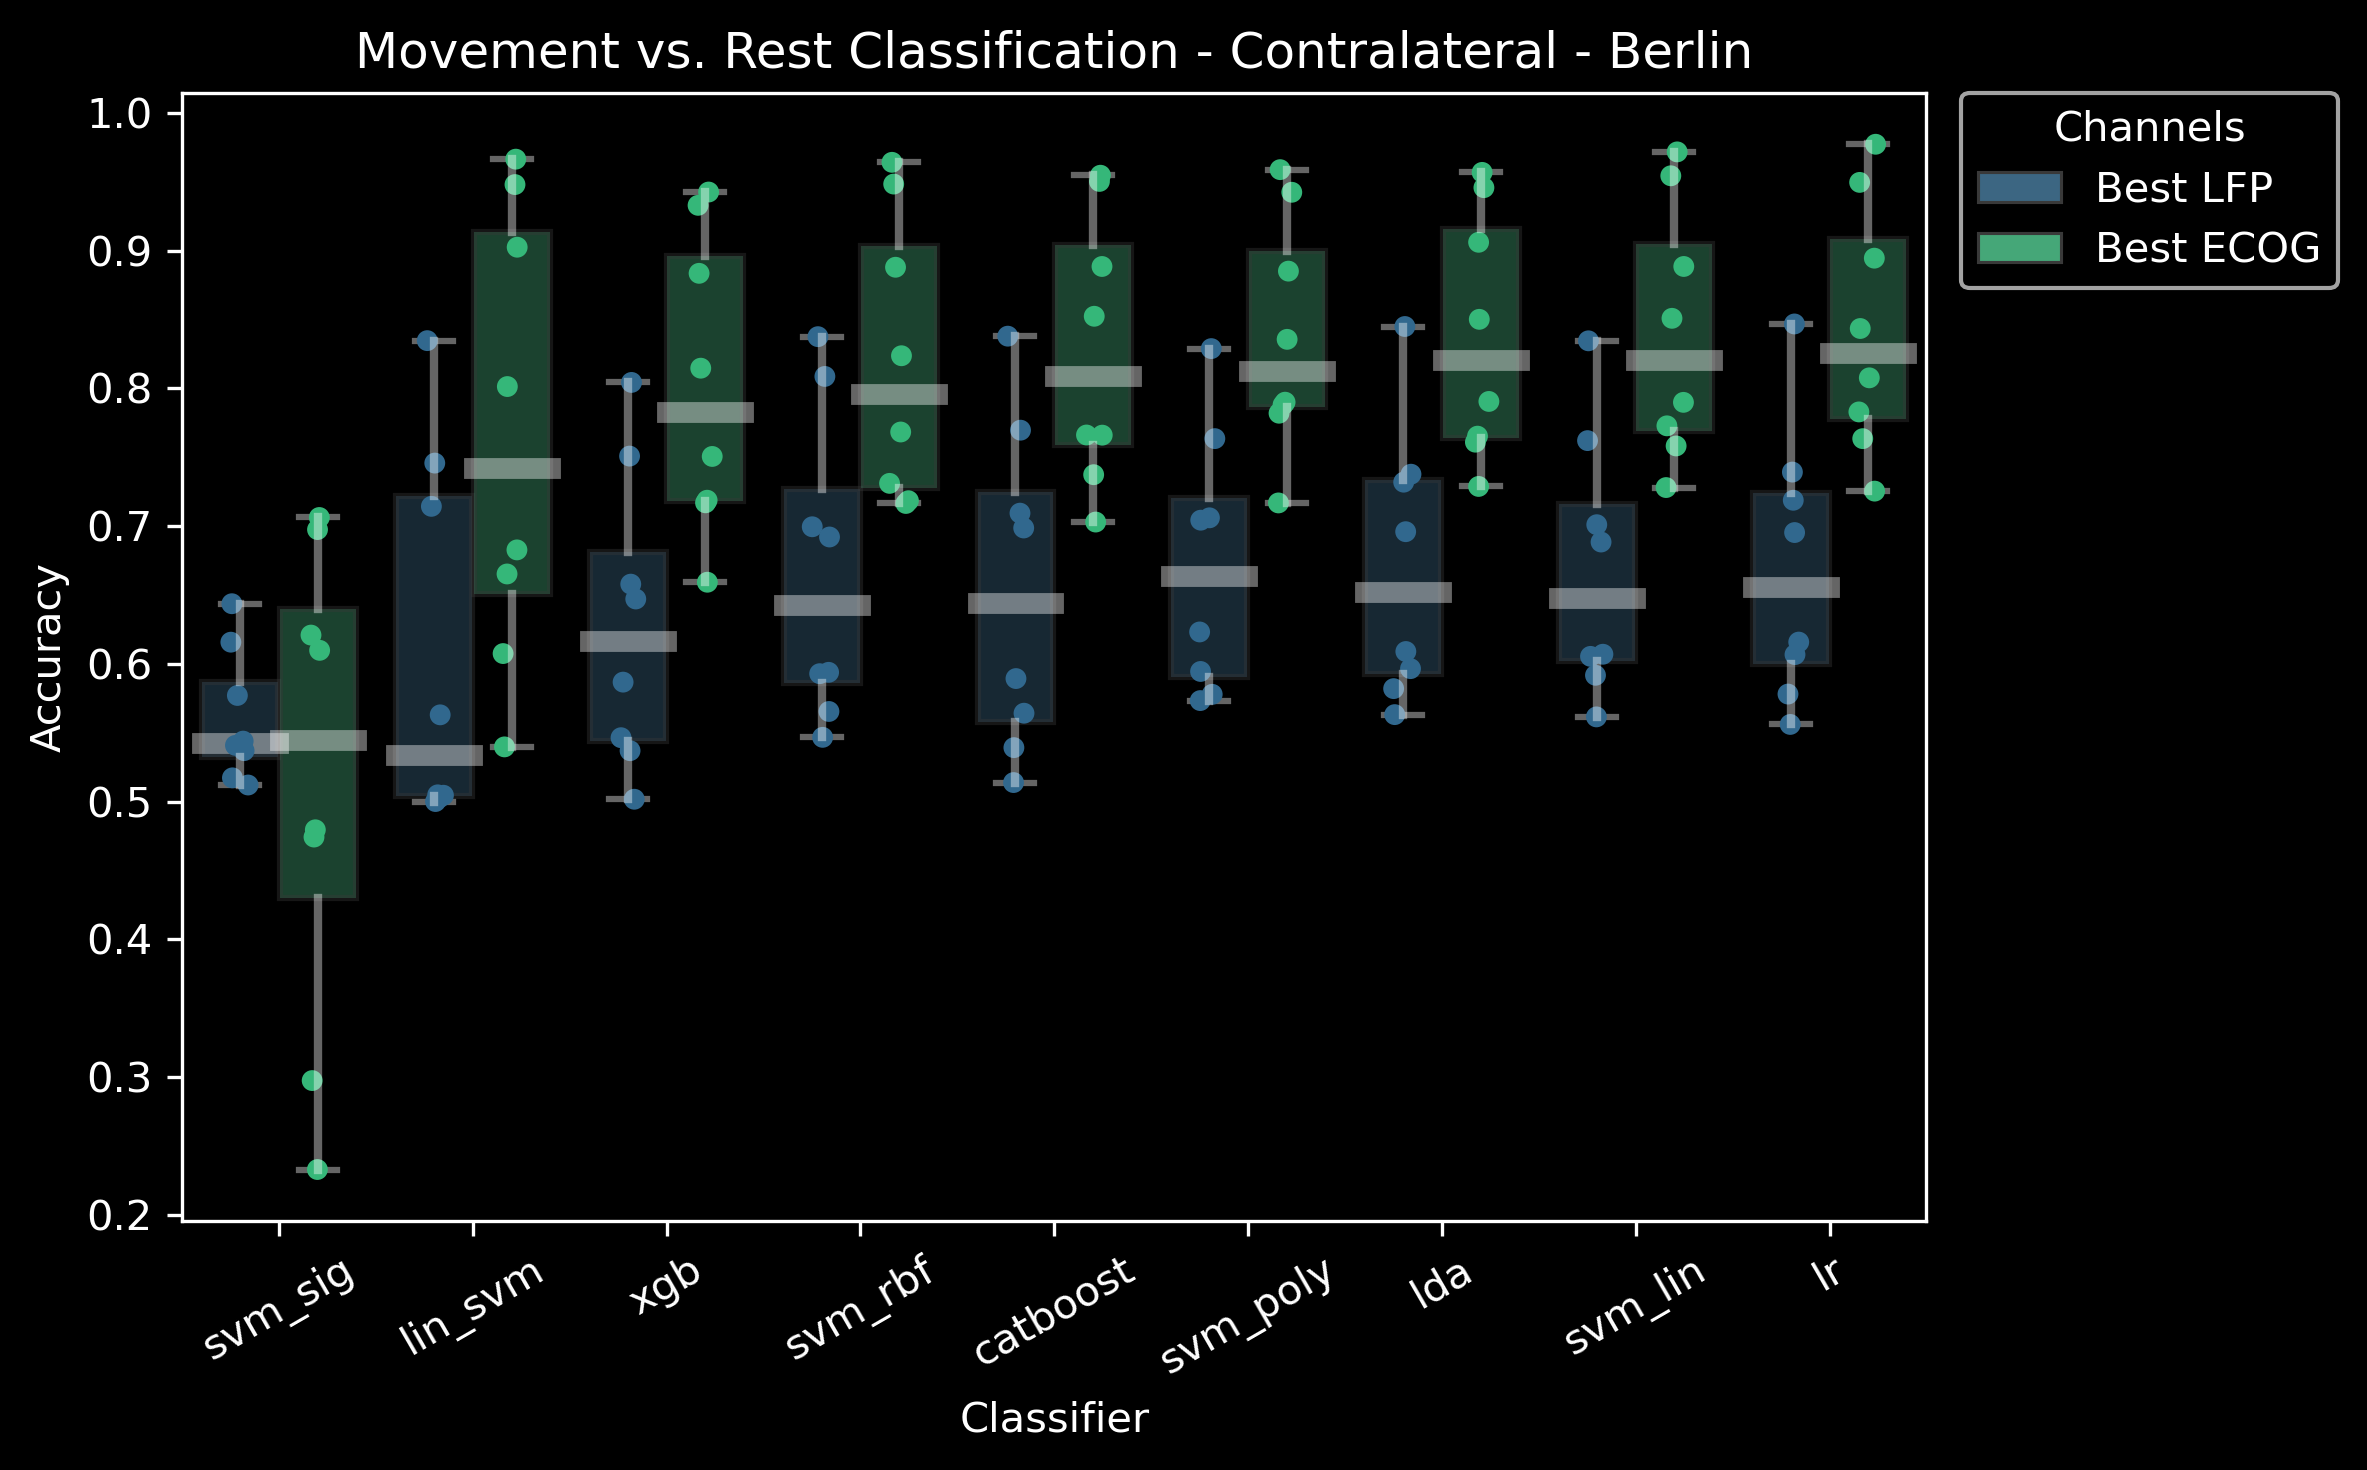

In [95]:
outpath = os.path.join(root, 'mov_contralat_compare_class_no_feat_norm_dark.png')
df = dfs_final['mov_contralat']
plt.style.use('dark_background')
alpha_box = 0.4
plt.figure(figsize=(8,5), dpi=300)
#order = ['lr', 'lda', 'svm_lin', 'xgb']
x = "Classifier"
y = "Accuracy"
hue = "Channel"
clfs = df['Classifier'].unique()
ecog_mean = dict()
df_ecog = df[df['Channel'] == 'Best ECOG']
for clf in clfs:
    ecog_mean[clf] = df_ecog[df_ecog['Classifier'] == clf]['Accuracy'].mean()
order = {k: v for k, v in sorted(ecog_mean.items(), key=lambda item: item[1])}.keys()
sb.boxplot(x=x, y=y, hue=hue, order=order, data=df, 
           palette="viridis", showmeans=False, boxprops=dict(alpha=alpha_box), 
           showcaps=True, showbox=True, showfliers=False, notch=False,
           whiskerprops={'linewidth':2, "zorder":10, "alpha":alpha_box, "color":'white'},
           capprops={"alpha":alpha_box,"color":'white'},
           medianprops=dict(linestyle='-', linewidth=5, color="white", alpha=alpha_box))

ax = sb.stripplot(x=x, y=y, hue=hue, order=order, data=df, 
                  palette="viridis", dodge=True, s=5)

plt.xticks(rotation=30)
xlabels = [item.get_text() for item in ax.get_xticklabels()]
new_xlabels = [xtick.replace(' ','\n') for xtick in xlabels]
ax.set_xticklabels(new_xlabels) 
#plt.xlabel(xlabel = 'Features (ms)')
handles, labels = ax.get_legend_handles_labels()
l = plt.legend(handles[:len(handles)//2], labels[:len(labels)//2], bbox_to_anchor=(1.02, 1), 
               loc=2, borderaxespad=0., title='Channels')
plt.title("Movement vs. Rest Classification - Contralateral - Berlin")
plt.tight_layout()
plt.savefig(outpath)